# XII. inventory.csv — Tồn kho


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

num_cols = [
    'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply',
    'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate',
    'year', 'month'
]
for col in num_cols:
    inventory_df[col] = pd.to_numeric(inventory_df[col], errors='coerce')

month_name_map = {
    1: 'Tháng 1', 2: 'Tháng 2', 3: 'Tháng 3', 4: 'Tháng 4', 5: 'Tháng 5', 6: 'Tháng 6',
    7: 'Tháng 7', 8: 'Tháng 8', 9: 'Tháng 9', 10: 'Tháng 10', 11: 'Tháng 11', 12: 'Tháng 12'
}
inventory_df['month_name'] = inventory_df['month'].map(month_name_map)

inventory_df['inventory_status'] = np.select(
    [
        (inventory_df['stockout_flag'] == 1) & (inventory_df['overstock_flag'] == 1),
        (inventory_df['stockout_flag'] == 1) & (inventory_df['overstock_flag'] == 0),
        (inventory_df['stockout_flag'] == 0) & (inventory_df['overstock_flag'] == 1)
    ],
    [
        'Tồn kho bất ổn',
        'Rủi ro thiếu hàng',
        'Rủi ro dư hàng'
    ],
    default='Cân bằng'
)

inventory_df['year_month'] = inventory_df['snapshot_date'].dt.to_period('M')

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [47]:
inventory_df.head(10)

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,month_name,inventory_status,year_month
0,2022-10-31,1,3,1,1,2,90.00,0.93,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10,Tháng 10,Rủi ro thiếu hàng,2022-10
1,2022-11-30,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11,Tháng 11,Rủi ro thiếu hàng,2022-11
2,2022-12-31,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12,Tháng 12,Rủi ro thiếu hàng,2022-12
3,2016-04-30,3,35,13,11,2,95.50,0.93,1,1,0,0.24,DragonWear MA-03,Casual,All-weather,2016,4,Tháng 4,Tồn kho bất ổn,2016-04
4,2016-05-31,3,36,11,10,1,108.00,0.97,1,1,0,0.22,DragonWear MA-03,Casual,All-weather,2016,5,Tháng 5,Tồn kho bất ổn,2016-05
5,2016-06-30,3,37,8,7,2,158.60,0.93,1,1,0,0.16,DragonWear MA-03,Casual,All-weather,2016,6,Tháng 6,Tồn kho bất ổn,2016-06
6,2016-07-31,3,39,11,9,2,130.00,0.93,1,1,0,0.19,DragonWear MA-03,Casual,All-weather,2016,7,Tháng 7,Tồn kho bất ổn,2016-07
7,2016-08-31,3,39,4,4,0,292.50,1.00,0,1,0,0.09,DragonWear MA-03,Casual,All-weather,2016,8,Tháng 8,Rủi ro dư hàng,2016-08
8,2016-09-30,3,40,7,6,0,200.00,1.00,0,1,0,0.13,DragonWear MA-03,Casual,All-weather,2016,9,Tháng 9,Rủi ro dư hàng,2016-09
9,2016-10-31,3,41,7,6,1,205.00,0.97,1,1,0,0.13,DragonWear MA-03,Casual,All-weather,2016,10,Tháng 10,Tồn kho bất ổn,2016-10


In [48]:
inventory_df.shape

(60247, 20)

In [49]:
inventory_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[us]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  str           
 13  category           60247 non-null  str           
 14  segment          

In [50]:
inventory_df.columns

Index(['snapshot_date', 'product_id', 'stock_on_hand', 'units_received',
       'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate',
       'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate',
       'product_name', 'category', 'segment', 'year', 'month', 'month_name',
       'inventory_status', 'year_month'],
      dtype='str')

In [51]:
overview_df = pd.DataFrame({
    'missing_count': inventory_df.isna().sum(),
    'missing_rate_%': (inventory_df.isna().mean() * 100).round(2),
    'n_unique': inventory_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
snapshot_date,0,0.00,126
product_id,0,0.00,1624
stock_on_hand,0,0.00,1895
units_received,0,0.00,360
units_sold,0,0.00,303
stockout_days,0,0.00,29
days_of_supply,0,0.00,9289
fill_rate,0,0.00,29
stockout_flag,0,0.00,2
overstock_flag,0,0.00,2


In [52]:
summary_df = pd.DataFrame({
    'snapshot_date_min': [inventory_df['snapshot_date'].min()],
    'snapshot_date_max': [inventory_df['snapshot_date'].max()],
    'unique_product_id': [inventory_df['product_id'].nunique()],
    'unique_product_name': [inventory_df['product_name'].nunique()],
    'unique_category': [inventory_df['category'].nunique()],
    'unique_segment': [inventory_df['segment'].nunique()]
})
summary_df

,snapshot_date_min,snapshot_date_max,unique_product_id,unique_product_name,unique_category,unique_segment
0,2012-07-31,2022-12-31,1624,1465,4,8


## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Nhóm tồn kho và luân chuyển


Đã lưu biểu đồ kết hợp tại: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/inventory_core_distribution_boxplot.png


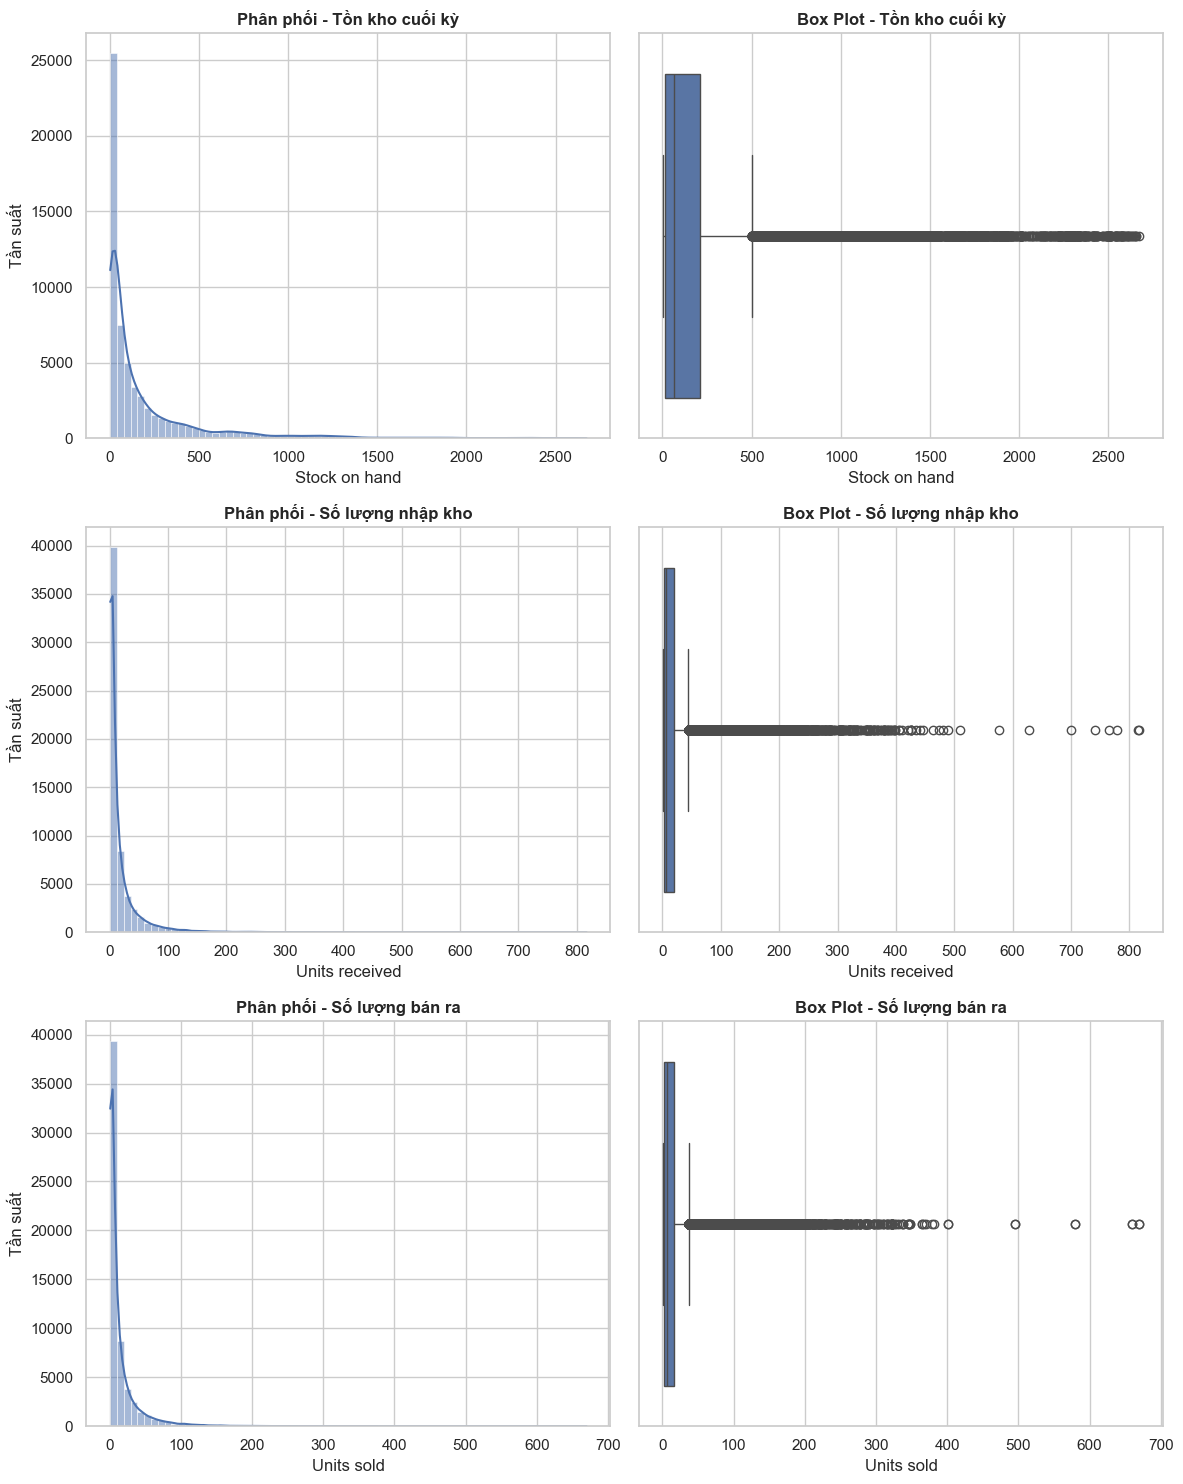

In [53]:
col_config_core = {
    'stock_on_hand': {'title': 'Tồn kho cuối kỳ', 'xlabel': 'Stock on hand', 'hist_kwargs': {'bins': 70}},
    'units_received': {'title': 'Số lượng nhập kho', 'xlabel': 'Units received', 'hist_kwargs': {'bins': 70}},
    'units_sold': {'title': 'Số lượng bán ra', 'xlabel': 'Units sold', 'hist_kwargs': {'bins': 70}}
}

core_cols = ['stock_on_hand', 'units_received', 'units_sold']

def plot_distribution_boxplot(df, con_cols_names, config_dict, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = config_dict.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Đã lưu biểu đồ kết hợp tại: {save_path}')

    plt.show()

plot_distribution_boxplot(
    inventory_df,
    core_cols,
    col_config_core,
    save_path=os.path.join(IMAGES_DIR, 'inventory_core_distribution_boxplot.png')
)

In [54]:
inventory_df[core_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,stock_on_hand,units_received,units_sold
count,60247.00,60247.00,60247.00
mean,189.30,18.05,15.42
std,316.98,34.08,28.40
min,3.00,1.00,1.00
1%,3.00,1.00,1.00
5%,3.00,1.00,1.00
25%,15.00,2.00,2.00
50%,62.00,6.00,6.00
75%,210.00,19.00,16.00
90%,532.00,47.00,39.00


**Nhận xét:**

- **Quan sát:**
  - Ba biến cốt lõi gồm Tồn kho (`stock_on_hand`), Nhập kho (`units_received`), và Bán ra (`units_sold`) đều có phân phối lệch phải (right-skewed) cực kỳ mạnh. 
  - Đồ thị Boxplot cho thấy `units_received` và `units_sold` tập trung rất dày đặc ở các giá trị thấp và có biên độ IQR hẹp. Trong khi đó, `stock_on_hand` vươn râu (whiskers) xa hơn hẳn và để lộ một dải vệt điểm ngoại lai (outliers) đặc và kéo dài về phía đuôi phải.

- **Insights:**
  - Quy chuẩn phân mảnh E-commerce: Lượng nhập-xuất hàng tháng vận hành ở thể tích quy mô siêu nhỏ đối với phần lớn các mã hàng (Long-tail SKUs). Tuy lượng bán ra đều đặn ở các mức thấp, rải rác, nhưng do lượng nhập nhỉnh hơn lượng bán đều đặn đã tạo nên những tảng băng "tồn kho đọng" (đại diện bởi các điểm Outliers khổng lồ của `stock_on_hand`).
  - Lõi chôn vốn chuỗi cung ứng: Các mã SKU thuộc vùng vệt ngoại lai của `stock_on_hand` chính là gốc

#### b. Nhóm hiệu quả tồn kho


Đã lưu biểu đồ kết hợp tại: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/inventory_efficiency_distribution_boxplot.png


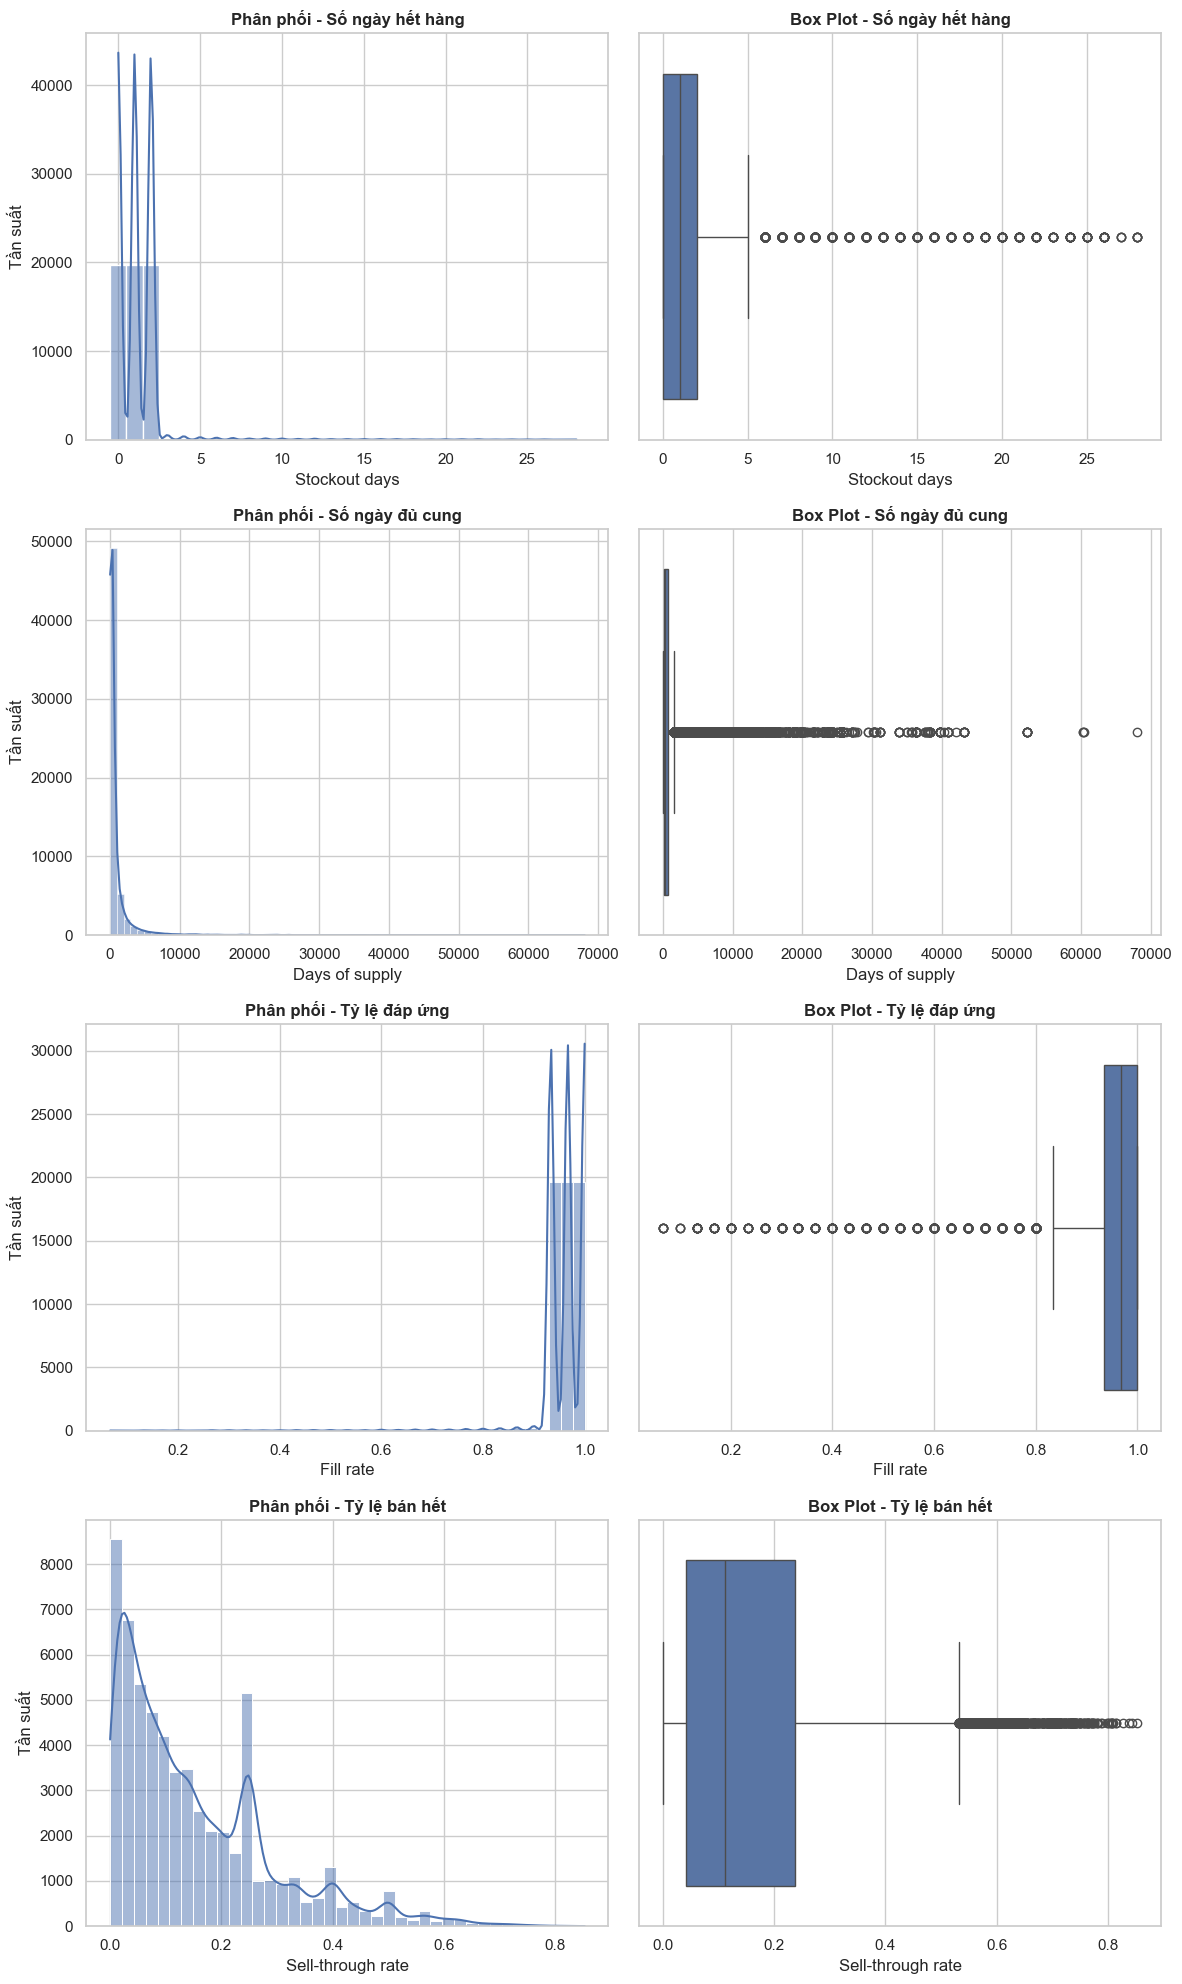

In [55]:
col_config_eff = {
    'stockout_days': {'title': 'Số ngày hết hàng', 'xlabel': 'Stockout days', 'hist_kwargs': {'discrete': True}},
    'days_of_supply': {'title': 'Số ngày đủ cung', 'xlabel': 'Days of supply', 'hist_kwargs': {'bins': 70}},
    'fill_rate': {'title': 'Tỷ lệ đáp ứng', 'xlabel': 'Fill rate', 'hist_kwargs': {'bins': 40}},
    'sell_through_rate': {'title': 'Tỷ lệ bán hết', 'xlabel': 'Sell-through rate', 'hist_kwargs': {'bins': 40}}
}

eff_cols = ['stockout_days', 'days_of_supply', 'fill_rate', 'sell_through_rate']
plot_distribution_boxplot(
    inventory_df,
    eff_cols,
    col_config_eff,
    save_path=os.path.join(IMAGES_DIR, 'inventory_efficiency_distribution_boxplot.png')
)

In [56]:
inventory_df[eff_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,stockout_days,days_of_supply,fill_rate,sell_through_rate
count,60247.00,60247.00,60247.00,60247.00
mean,1.16,912.68,0.96,0.15
std,1.62,2587.62,0.05,0.14
min,0.00,5.20,0.07,0.00
1%,0.00,20.00,0.77,0.00
5%,0.00,39.00,0.93,0.01
25%,0.00,96.00,0.93,0.04
50%,1.00,240.00,0.97,0.11
75%,2.00,683.10,1.00,0.24
90%,2.00,1926.12,1.00,0.35


In [57]:
q1 = inventory_df['days_of_supply'].quantile(0.25)
q3 = inventory_df['days_of_supply'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (inventory_df['days_of_supply'] < lower_bound) | (inventory_df['days_of_supply'] > upper_bound)
outlier_count = int(outlier_mask.sum())
outlier_rate = outlier_count / len(inventory_df) * 100

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Lower bound: {lower_bound:,.2f}')
print(f'Upper bound: {upper_bound:,.2f}')
print(f'Số lượng outlier (IQR): {outlier_count:,}')
print(f'Ty le outlier (IQR): {outlier_rate:.2f}%')

Q1: 96.00
Q3: 683.10
IQR: 587.10
Lower bound: -784.65
Upper bound: 1,563.75
Số lượng outlier (IQR): 7,455
Ty le outlier (IQR): 12.37%


**Nhận xét:**

- **Quan sát:**
  - Số ngày đủ cung (`days_of_supply`): Mật độ tập trung ở phần đầu cực nhỏ, nhưng Boxplot bóc trần một dải râu kéo dài vô cực tới hàng trăm, hàng ngàn ngày (Vượt Upper bound rất nhiều điểm). 
  - Tỷ lệ đáp ứng (`fill_rate`) và Bán hết (`sell_through_rate`): Histogram của 2 biến này rách ra thành 2 hai đầu thái cực. Một cụm phân bổ dày đặc ở sát mốc thấp nhất (0%) và một cụm dồn ứ ở vách mốc trần hoàn hảo (100%).

- **Insights:**
  - Sự phân cực hiệu suất (Polarized Performance): Hoạt động Supply Chain không bình ổn ở khúc giữa mà gãy đôi. Vùng trần (100% fill_rate) là tệp "Hero SKUs" bán tới đâu đáp ứng rạch ròi mượt mà tới đó. Nhưng cái giá của nó là hệ thống chấp nhận ôm một lượng lớn Deadstock rớt vào đáy (0% sell-through) nằm chắp vá làm đẩy số `days_of_supply` của tập này lên thành vĩnh viễn (Vài năm không bán hết). 
  - Rủi ro Buffer Stock: Để tránh việc `stockout_days` cao, chiến lược của tổng kho dường như là nhồi chứa (Overstock) bất chấp rủi ro vòng quay. 

- **Gợi ý hành động:**
  - Feature Engineering cho Mô hình dự báo: Biến `days_of_supply` cần được log-transform và chia bin (vd: an toàn < 30, bất ổn 30-90, đọng vốn > 90) trước khi ghép vào ML/Forecasting vì dải số liên tục của nó bị outliers bóp méo quá nặng.
  - Tối ưu Reorder Point (ROP): Review lại thuật toán Reorder. Nếu một mã hàng có `sell_through_rate` thấp < 10% ở 2 chu kỳ liên tiếp, ngắt ngay công tắc nhập hàng luân chuyển (`units_received` = 0) để kìm hãm sự phình to của đồ thị `days_of_supply`.

### 1.1.2. Biến phân loại (Categorical)


Đã lưu biểu đồ categorical tại: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/inventory_categorical_distribution.png


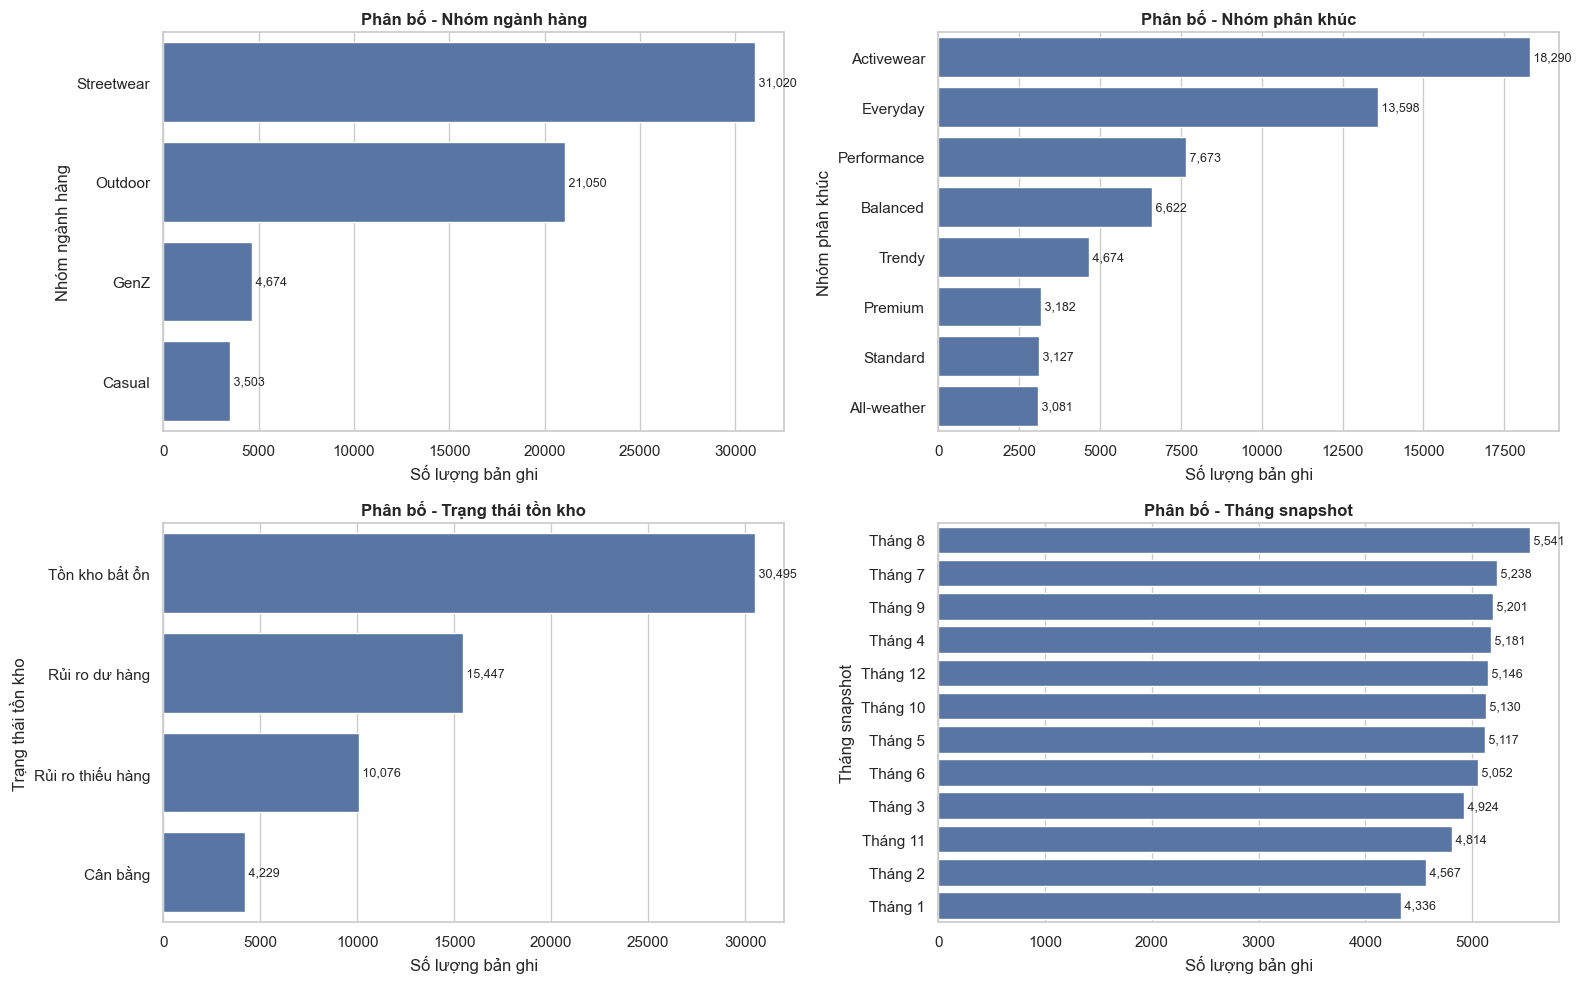

In [70]:
COL_INFO = {
    'category': {'name': 'Nhóm ngành hàng', 'unit': 'bản ghi'},
    'segment': {'name': 'Nhóm phân khúc', 'unit': 'bản ghi'},
    'inventory_status': {'name': 'Trạng thái tồn kho', 'unit': 'bản ghi'},
    'month_name': {'name': 'Tháng snapshot', 'unit': 'bản ghi'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('khong_xac_dinh').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhóm'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Đã lưu biểu đồ categorical tại: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    inventory_df,
    ['category', 'segment', 'inventory_status', 'month_name'],
    save_path=os.path.join(IMAGES_DIR, 'inventory_categorical_distribution.png')
)

In [59]:
flag_stats = pd.DataFrame({
    'stockout_flag': inventory_df['stockout_flag'].value_counts().sort_index(),
    'overstock_flag': inventory_df['overstock_flag'].value_counts().sort_index(),
    'reorder_flag': inventory_df['reorder_flag'].value_counts().sort_index()
}).fillna(0).astype(int)
flag_stats

,stockout_flag,overstock_flag,reorder_flag
0,19676,14305,60247
1,40571,45942,0


**Nhận xét:**

- **Quan sát:**
  - Trạng thái tồn kho (`inventory_status` & `Flags`): Tuy nhóm trạng thái "Cân bằng" chiếm chủ đạo, dữ liệu bật đèn đỏ ở phần Overstock_flag (Rủi ro dư hàng) với lượng bản ghi khá cao. Ngược lại, Số lượng rơi vào Stockout_flag (Đứt hàng) thấp hơn tương đối. Trạng thái "Tồn kho bất ổn" hiếm nhưng vẫn có mặt.
  - Snapshot Tháng: Lượng bản ghi Snapshot chốt tồn tại các tháng giữ đều đặn, không có rớt data.
  - Category và Segment: Sự lệch pha giữa các Category sản phẩm khá rõ nét.

- **Insights:**
  - Áp lực tiền chết (Cashflow pressure): Tồn kho trong tập dữ liệu này đang nghiêng hẳn về rủi ro Dư cung (Overstock). Ngành thời trang, đặc biệt là E-commerce có rào cản hoàn trả (Return rate) cao, đã khiến doanh nghiệp phải đắp phễu kho dày (Buffer stock lớn). Điều này bảo vệ được tỷ lệ Fill_rate nhưng lại chôn vốn (Cash-tied up).

- **Gợi ý hành động:**
  - Pivot theo Category: Khi phân tích chi tiết, gộp `inventory_status` chéo với `category` để chỉ đích danh nhóm ngành hàng nào đang chôn cục vốn lớn nhất do Overstock, ngành hàng nào mang rủi ro đứt hàng gãy trend cao.
  - Trigger tái tạo Reorder point: Tính toán lại mức an toàn (Safety Stock). Với nhóm Segment/Category có Overstock flag liên tục, giảm hệ số Reorder Level xuống và siết chặt số lần `units_received` mỗi tháng hợp lý hơn.

### 1.1.3. Biến thời gian


In [60]:
monthly_inventory = (
    inventory_df.groupby('year_month')
    .agg(
        avg_stock_on_hand=('stock_on_hand', 'mean'),
        avg_units_sold=('units_sold', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        avg_fill_rate=('fill_rate', 'mean')
    )
    .reset_index()
)
monthly_inventory['year_month'] = monthly_inventory['year_month'].astype(str)
monthly_inventory.head()

,year_month,avg_stock_on_hand,avg_units_sold,avg_days_of_supply,avg_fill_rate
0,2012-07,59.99,18.86,93.25,0.97
1,2012-08,62.05,23.60,99.43,0.94
2,2012-09,64.90,17.22,144.85,0.95
3,2012-10,66.81,15.15,181.29,0.95
4,2012-11,73.32,15.21,228.74,0.96


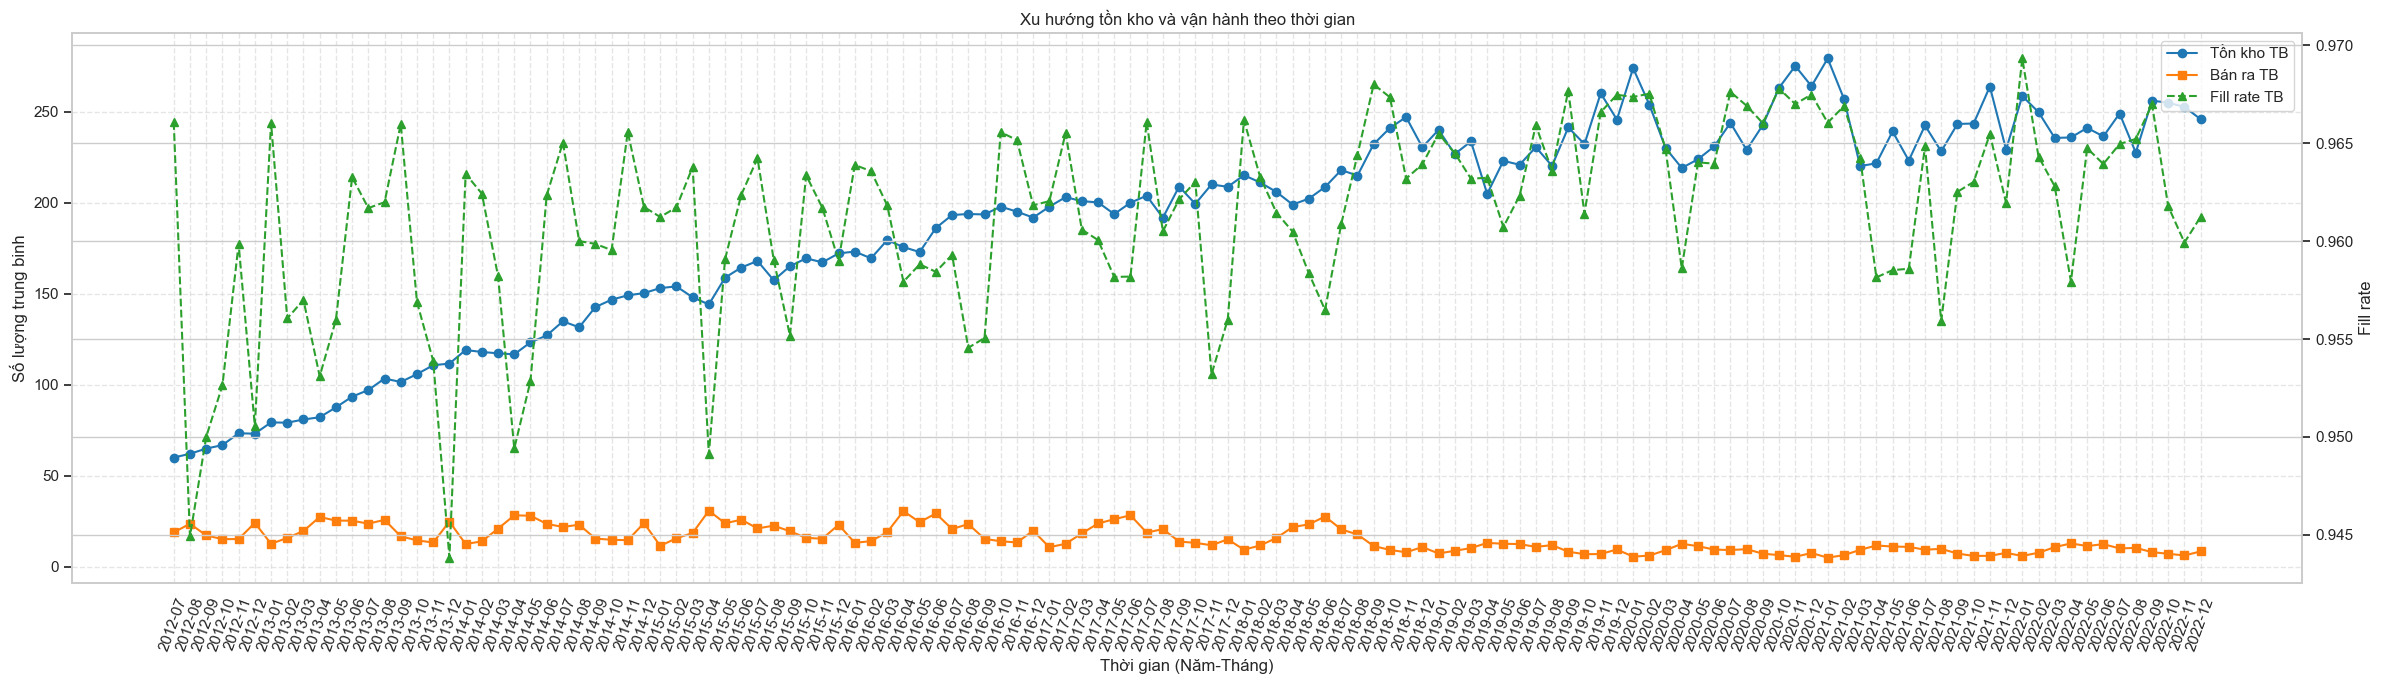

In [61]:
fig, ax1 = plt.subplots(figsize=(24, 7))

ax1.plot(monthly_inventory['year_month'], monthly_inventory['avg_stock_on_hand'], color='tab:blue', marker='o', label='Tồn kho TB')
ax1.plot(monthly_inventory['year_month'], monthly_inventory['avg_units_sold'], color='tab:orange', marker='s', label='Bán ra TB')
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Số lượng trung binh')
ax1.tick_params(axis='x', rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_inventory['year_month'], monthly_inventory['avg_fill_rate'], color='tab:green', marker='^', linestyle='--', label='Fill rate TB')
ax2.set_ylabel('Fill rate')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.title('Xu hướng tồn kho và vận hành theo thời gian')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

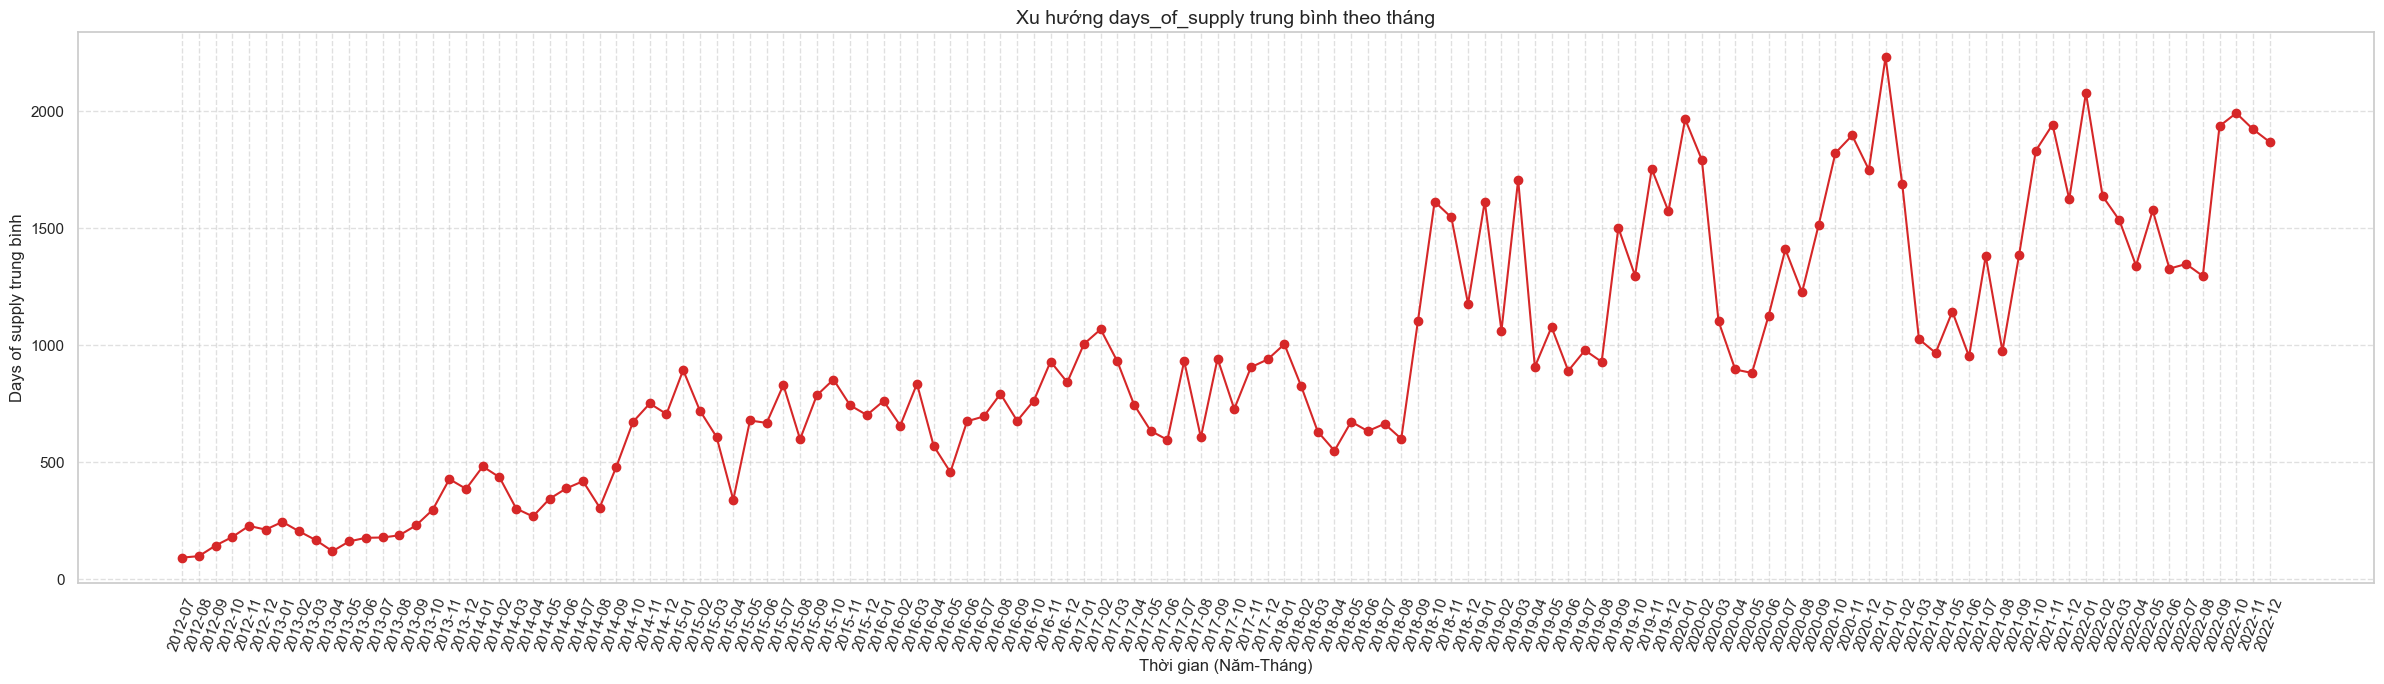

In [62]:
fig, ax = plt.subplots(figsize=(24, 7))
ax.plot(monthly_inventory['year_month'], monthly_inventory['avg_days_of_supply'], color='tab:red', marker='o', linestyle='-')
ax.set_title('Xu hướng days_of_supply trung bình theo tháng', fontsize=14)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Days of supply trung bình')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Vận hành theo thời gian (AVG Stock vs Sold): Đường `avg_stock_on_hand` (Tồn TB) chạy rất lượn sóng và thường xuyên duy trì mặt bằng cao hơn hẳn so với đường `avg_units_sold` (Bán ra TB). 
  - Fill Rate & Days of Supply: Đồ thị `avg_days_of_supply` giật lên những đỉnh cao vào một số tháng nhất định, trùng với nhịp chùng xuống của Sales. `Fill_rate` lại có vẻ khá bình ổn trong phần lớn thời gian.

- **Insights:**
  - Hiệu ứng Bullwhip / Chạy chu kỳ thời trang: Những cái giật đỉnh của `Days of supply` hoặc Tồn kho lớn là dấu hiệu điển hình của việc "Nhập gối đầu" mùa mới (ví dụ nhập đồ Thu Đông từ tháng Hè) khi Sales món đó chưa xuất hiện. Giai đoạn hàng về ngập kho tạo ra Overstock cục bộ trước khi các Mega Sales xả bớt hàng đi.
  - Ưu tiên Dịch vụ > Tối ưu phí kho: Hệ thống có xu hướng giữ hàng để bảo vệ `Fill_rate` (tức là bảo vệ sự hài lòng của khách). Không để khách đặt mà báo hết hàng. 

- **Gợi ý hành động:**
  - Đồng bộ Time-series với Marketing: Khớp các tháng có Tồn kho TB cao / Days of supply cao với lịch tung Campaigns (`promotions.csv`). Nếu kho đã ôm hàng nhưng Promo lại bị delay hoặc chưa đủ sâu (Discount Value bé), Tồn kho sẽ mắc kẹt.

## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [63]:
corr_cols = ['stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'sell_through_rate']
corr_df = inventory_df[corr_cols].corr()
corr_df

,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,sell_through_rate
stock_on_hand,1.00,0.41,0.41,-0.05,0.37,0.05,-0.37
units_received,0.41,1.00,1.00,0.12,-0.11,-0.12,0.14
units_sold,0.41,1.00,1.00,0.12,-0.11,-0.12,0.14
stockout_days,-0.05,0.12,0.12,1.00,-0.04,-1.00,0.35
days_of_supply,0.37,-0.11,-0.11,-0.04,1.00,0.04,-0.32
fill_rate,0.05,-0.12,-0.12,-1.00,0.04,1.00,-0.35
sell_through_rate,-0.37,0.14,0.14,0.35,-0.32,-0.35,1.00


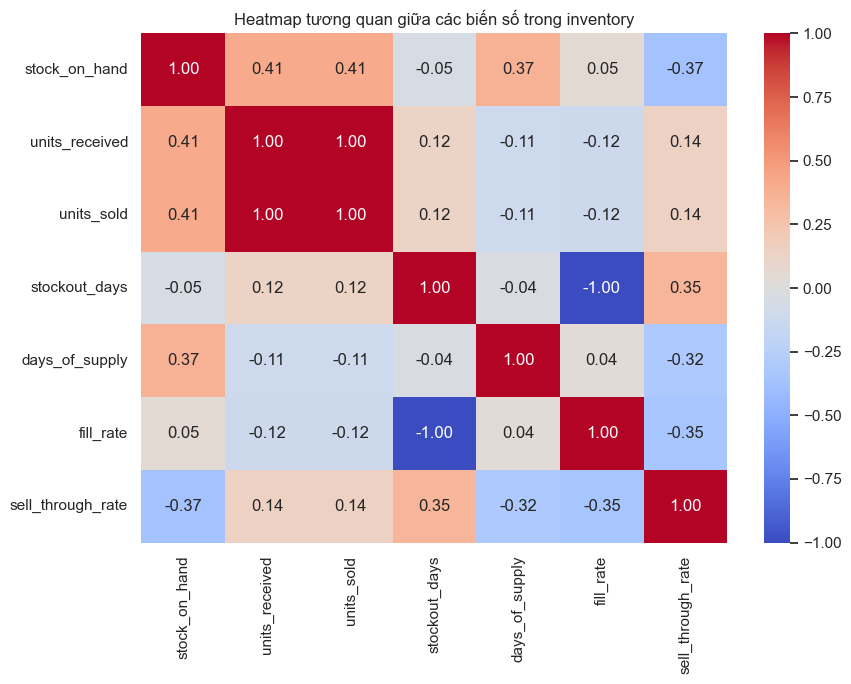

In [64]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các biến số trong inventory')
plt.tight_layout()
plt.show()

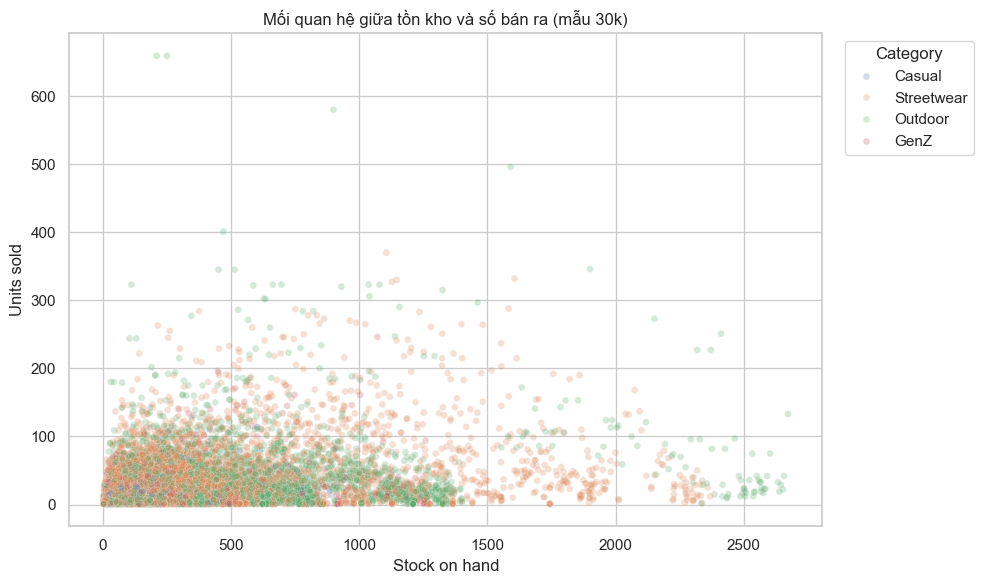

In [65]:
sample_scatter = inventory_df.sample(n=min(30000, len(inventory_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x='stock_on_hand',
    y='units_sold',
    hue='category',
    alpha=0.25,
    s=24
)
plt.title('Mối quan hệ giữa tồn kho và số bán ra (mẫu 30k)')
plt.xlabel('Stock on hand')
plt.ylabel('Units sold')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2.2. Phân tích cross table


In [66]:
cross_abs = pd.crosstab(inventory_df['category'], inventory_df['stockout_flag'])
cross_abs

stockout_flag,0,1
category,,
Casual,1184,2319
GenZ,1482,3192
Outdoor,6873,14177
Streetwear,10137,20883


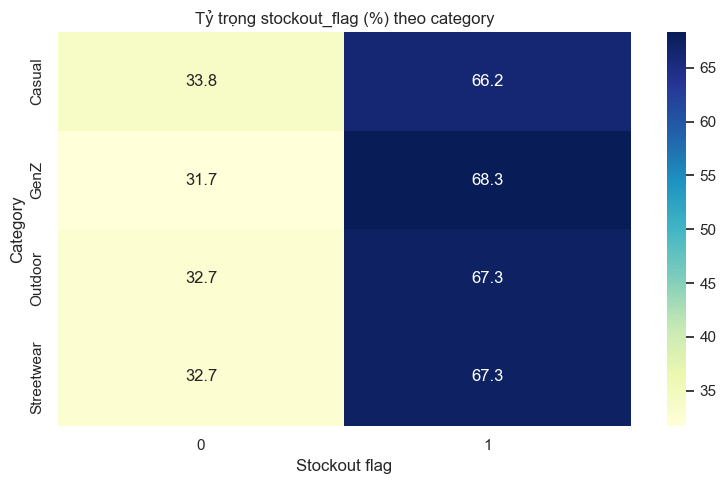

In [67]:
cross_row_pct = pd.crosstab(
    inventory_df['category'],
    inventory_df['stockout_flag'],
    normalize='index'
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(cross_row_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Tỷ trọng stockout_flag (%) theo category')
plt.xlabel('Stockout flag')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

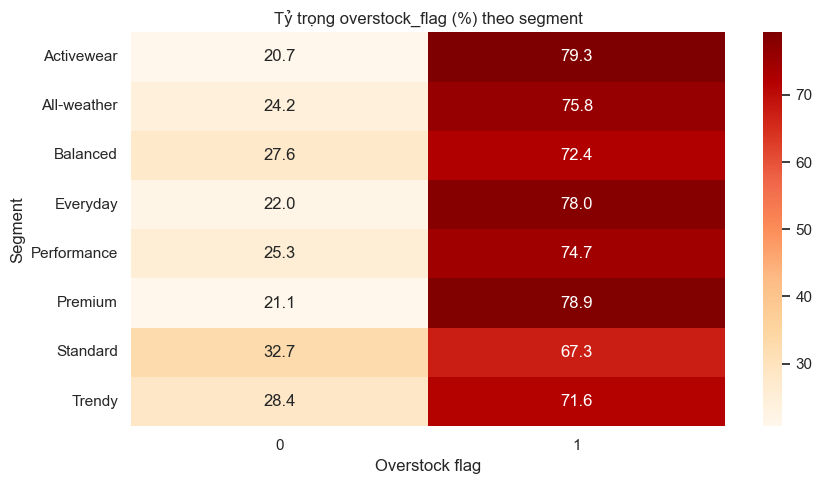

In [68]:
segment_overstock = pd.crosstab(inventory_df['segment'], inventory_df['overstock_flag'], normalize='index') * 100

plt.figure(figsize=(9, 5))
sns.heatmap(segment_overstock, annot=True, fmt='.1f', cmap='OrRd')
plt.title('Tỷ trọng overstock_flag (%) theo segment')
plt.xlabel('Overstock flag')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

In [69]:
category_kpi = (
    inventory_df.groupby('category', as_index=False)
    .agg(
        avg_stock_on_hand=('stock_on_hand', 'mean'),
        avg_units_sold=('units_sold', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_sell_through_rate=('sell_through_rate', 'mean')
    )
    .sort_values('avg_stock_on_hand', ascending=False)
)
category_kpi

,category,avg_stock_on_hand,avg_units_sold,avg_days_of_supply,avg_fill_rate,avg_sell_through_rate
2,Outdoor,225.65,16.03,1068.84,0.96,0.14
3,Streetwear,185.67,16.49,887.14,0.96,0.16
1,GenZ,125.11,10.42,718.81,0.96,0.17
0,Casual,88.64,8.91,459.13,0.96,0.17


### **Câu hỏi: Xu hướng thanh toán theo thời gian tác động đến doanh thu và có mối liên hệ như thế nào với hiệu quả quản lý tồn kho?**

#### Câu hỏi nhỏ 1: Những tháng có sự gia tăng của các phương thức thanh toán trả sau hoặc trả góp có giúp đẩy nhanh tốc độ luân chuyển hàng hóa (sell_through_rate) và làm tăng doanh thu đột biến hay không?

#### Câu hỏi nhỏ 2: Tình trạng ứ đọng vốn do lưu kho quá mức (Overstock) có xảy ra đồng thời với các giai đoạn dòng tiền doanh thu về chậm do xu hướng thanh toán bị kéo giãn?

#### Câu hỏi nhỏ 3: Tỷ lệ đáp ứng đơn hàng (Fill rate) thay đổi ra sao trong các chu kỳ mua sắm lớn - nơi ghi nhận các xu hướng thanh toán nhanh (như ví điện tử) đòn bẩy cho đỉnh doanh thu?